In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
seed_val = 42
np.random.seed(seed_val)
torch.manual_seed(seed_val)

In [2]:
class AutoencoderDataset(Dataset):
    def __init__(self, data_tensor):
        self.data_tensor = data_tensor#.cuda()

    def __len__(self):
        return self.data_tensor.size(0)

    def __getitem__(self, idx):
        # For an autoencoder, X=Y (We need to reconstruct the input)
        x = self.data_tensor[idx]
        return x, x

In [3]:
# Charger les jeux d'entraînement et de test directement
train_df = pd.read_csv('../../../data/train_resample_standard_all.csv')
val_df = pd.read_csv('../../../data/test_resample_standard_all.csv')

# Print shapes
print("Train shape:", train_df.shape)
print("Test shape:", val_df.shape)

print(f"Total aggregate rows: {train_df.shape[0] + val_df.shape[0]}")


# Préparer tes données pour l'entraînement
data_id_train = train_df["apogee_id"]
data_target_train = train_df[["TEFF", "J", "H", "K", "LOGG"]]
train_data = train_df.drop(columns=["apogee_id", "TEFF", "J", "H", "K", "LOGG"]).astype('float32')

# Préparer tes données pour la validation (test final)
data_id_val = val_df["apogee_id"]
data_target_val = val_df[["TEFF", "J", "H", "K", "LOGG"]]
val_data = val_df.drop(columns=["apogee_id", "TEFF", "J", "H", "K", "LOGG"]).astype('float32')

# Convertir en tenseurs PyTorch directement
train_tensor = torch.tensor(train_data.values, dtype=torch.float32)
val_tensor = torch.tensor(val_data.values, dtype=torch.float32)




# Créer les datasets PyTorch correspondants
train_dataset = AutoencoderDataset(train_tensor)
val_dataset = AutoencoderDataset(val_tensor)

# Créer les DataLoaders correspondants
#train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True, num_workers=4, persistent_workers=True)
#val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False, num_workers=4, persistent_workers=True)
#train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True, pin_memory=True, pin_memory_device="cuda:0")
#val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False, pin_memory=True, pin_memory_device="cuda:0")

class DL():
    def __init__(self, ds, batch_size):
        self.ds = ds.cuda()
        self.batch_size = batch_size

    def __iter__(self):
        def inner():
            idx = torch.randperm(len(self.ds))
            for i in range(len(self.ds)//self.batch_size):
                b = self.ds[idx[i*self.batch_size:(i+1)*self.batch_size]]
                yield b, b

        return inner()

train_loader = DL(train_tensor,  batch_size=1024)
val_loader = DL(val_tensor, batch_size=1024)

# Optionnel : créer un tenseur global si nécessaire pour les visualisations plus tard :
full_data_tensor = torch.cat([train_tensor, val_tensor], dim=0)
data_id = pd.concat([data_id_train, data_id_val], ignore_index=True)





Train shape: (129124, 23)
Test shape: (32282, 23)
Total aggregate rows: 161406


In [4]:
class VAE(nn.Module):
    def __init__(self, input_dim=17, latent_dim=2):
        super(VAE, self).__init__()
        # -------------------
        # Encoder
        # -------------------
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(negative_slope=0.01),

            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(negative_slope=0.01)
        )
        # Two head for mean and variance log
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

        # -------------------
        # Decoder
        # -------------------
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(negative_slope=0.01),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(negative_slope=0.01),

            nn.Linear(32, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)  # Calcul de l'écart-type
        eps = torch.randn_like(std)    # Random noise
        return mu + eps * std          # Reparametrisation

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


In [5]:
# Device et dossiers
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

output_folder = "output_dataset"
os.makedirs(output_folder, exist_ok=True)
weight_folder = "output_weight"
os.makedirs(weight_folder, exist_ok=True)

num_epochs = 2000
patience = 2000
regul_param = 0.05
dims = [2, 3, 4]
# Boucle sur les dimensions latentes
for latent_dim in dims:
    print(f"\nTraining VAE with latent dimension: {latent_dim}")

    model = VAE(input_dim=17, latent_dim=latent_dim).to(device)
    #model.compile()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for X_batch, _ in train_loader:
            X_batch = X_batch#.to(device)
            optimizer.zero_grad()
            x_recon, mu, logvar = model(X_batch)
            recon_loss = criterion(x_recon, X_batch)
            kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            loss = recon_loss + regul_param * kl_loss
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(train_tensor)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, _ in val_loader:
                X_batch = X_batch#.to(device)
                x_recon, mu, logvar = model(X_batch)
                recon_loss = criterion(x_recon, X_batch)
                kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
                loss = recon_loss + regul_param * kl_loss
                val_loss += loss.item() * X_batch.size(0)
        val_loss /= len(val_tensor)

        print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            model_file = os.path.join(weight_folder, f"best_vae_{latent_dim}D.pth")
            torch.save(model.state_dict(), model_file)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stop!")
                break

    # Charger le meilleur modèle
    model.load_state_dict(torch.load(model_file))
    model.eval()

    # Projection complète train+test pour visualisation finale
    with torch.no_grad():
        full_tensor_device = full_data_tensor.to(device)
        mu, _ = model.encode(full_tensor_device)
    latent_embeddings = mu.cpu().numpy()

    # Sauvegarde CSV claire
    df_latent = pd.DataFrame(latent_embeddings, columns=[f"latent_{i+1}" for i in range(latent_dim)])
    df_latent.insert(0, "apogee_id", data_id)

    output_file = os.path.join(output_folder, f"VAE_latent_space_{latent_dim}D.csv")
    df_latent.to_csv(output_file, index=False)
    print(f"Latent space {latent_dim}D saved to {output_file}")

Using device: cuda

Training VAE with latent dimension: 2
Epoch [1/2000]  Train Loss: 1.052622 | Val Loss: 0.916692
Epoch [2/2000]  Train Loss: 0.815128 | Val Loss: 0.692834
Epoch [3/2000]  Train Loss: 0.662494 | Val Loss: 0.612444
Epoch [4/2000]  Train Loss: 0.605414 | Val Loss: 0.573656
Epoch [5/2000]  Train Loss: 0.576772 | Val Loss: 0.550063
Epoch [6/2000]  Train Loss: 0.558323 | Val Loss: 0.537034
Epoch [7/2000]  Train Loss: 0.546538 | Val Loss: 0.526903
Epoch [8/2000]  Train Loss: 0.537486 | Val Loss: 0.520051
Epoch [9/2000]  Train Loss: 0.531277 | Val Loss: 0.514581
Epoch [10/2000]  Train Loss: 0.526657 | Val Loss: 0.510896
Epoch [11/2000]  Train Loss: 0.522935 | Val Loss: 0.506351
Epoch [12/2000]  Train Loss: 0.519852 | Val Loss: 0.503575
Epoch [13/2000]  Train Loss: 0.517104 | Val Loss: 0.501115
Epoch [14/2000]  Train Loss: 0.514589 | Val Loss: 0.500720
Epoch [15/2000]  Train Loss: 0.512424 | Val Loss: 0.498783
Epoch [16/2000]  Train Loss: 0.509846 | Val Loss: 0.495007
Epoch [

In [50]:
a = torch.ones(5).cuda()

print(a.device)

a *a

cuda:0


tensor([1., 1., 1., 1., 1.], device='cuda:0')

In [6]:

with torch.no_grad():
    full_data_gpu = full_data_tensor.to(device)
    mu, _ = model.encode(full_data_gpu)
    latent_2d = mu.cpu().numpy()


print("Lattend space shape :", latent_2d.shape)  # Devrait être (175809, 2)



Lattend space shape : (161406, 4)


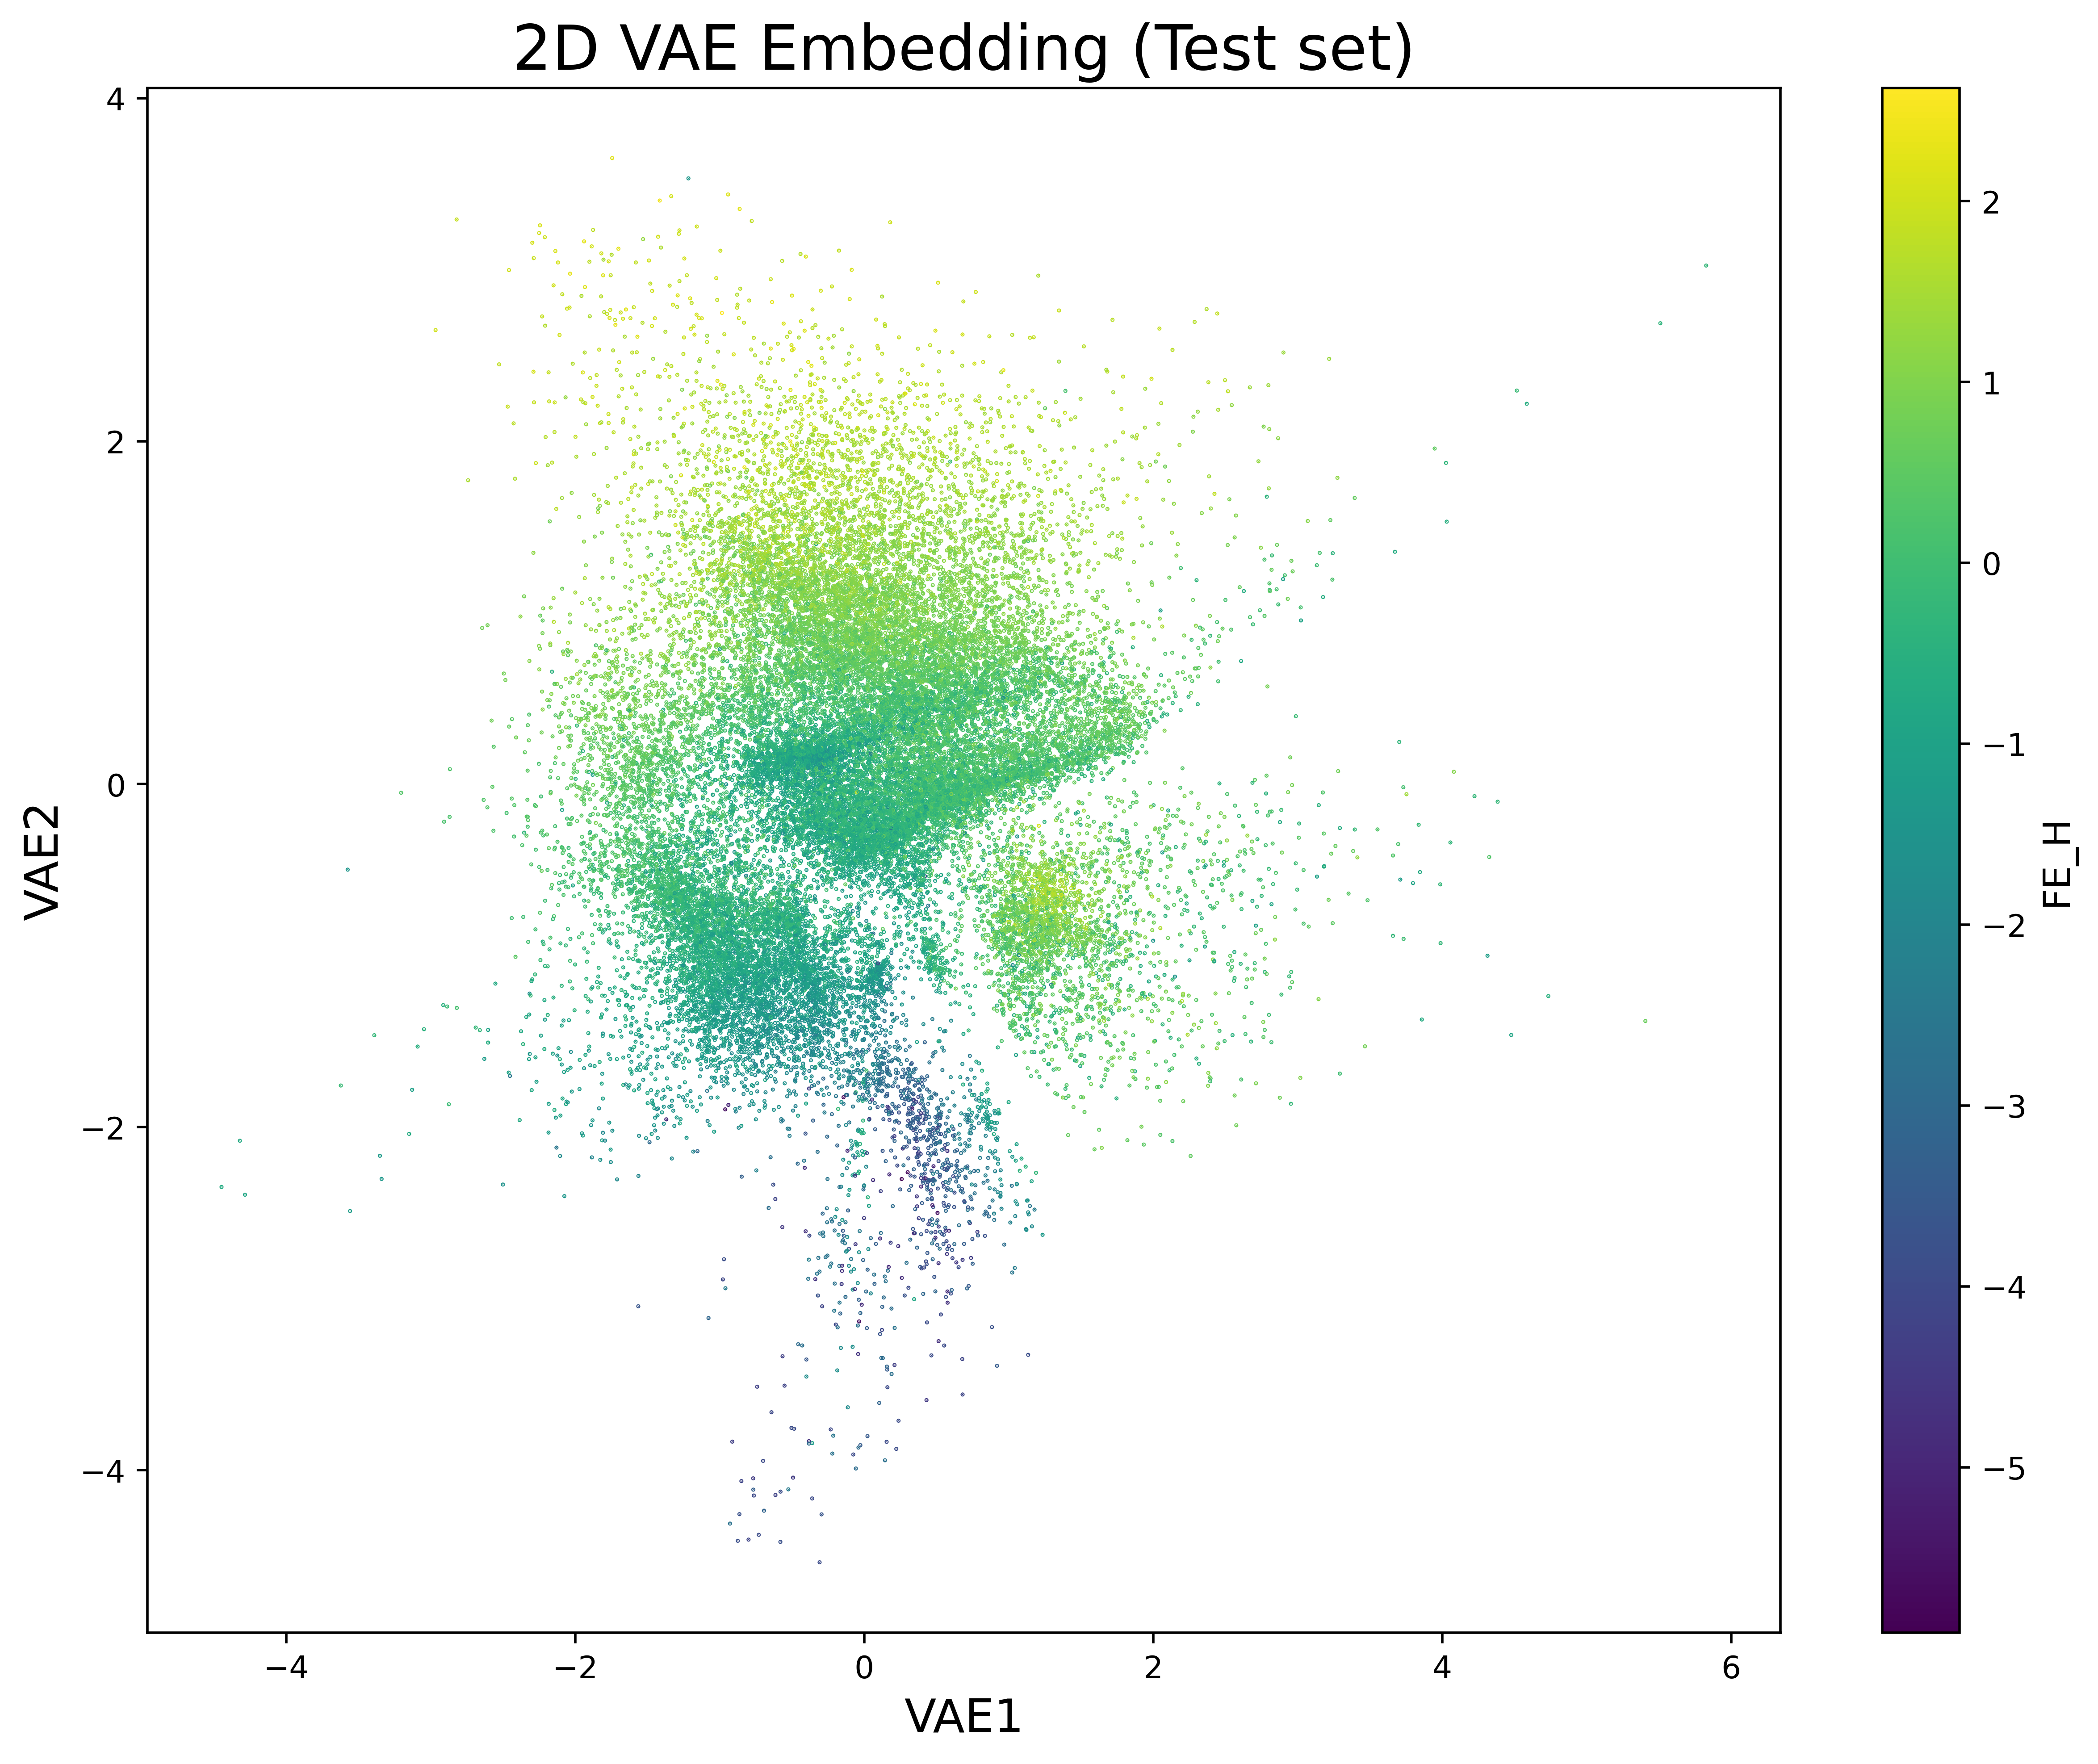

In [7]:
# Charger explicitement les embeddings depuis le CSV
data_to_plot = pd.read_csv("output_dataset/VAE_latent_space_2D.csv")


val_df_fe_h = val_df[['apogee_id', 'FE_H', 'TEFF']]
# get fe_h_values by merging with val_data
df_merged = pd.merge(data_to_plot, val_df_fe_h, on='apogee_id', how='inner')

# get latent_1 and latent_2 as numpy arrays
latent_1 = df_merged["latent_1"].values
latent_2 = df_merged["latent_2"].values
fe_h = df_merged["FE_H"].values

# Plot clair des embeddings avec FE_H comme couleur
fig = plt.figure(figsize=(10, 8), dpi=500)
ax = fig.add_subplot(1, 1, 1)

ax.set_xlabel('VAE1', fontsize=15)
ax.set_ylabel('VAE2', fontsize=15)
ax.set_title('2D VAE Embedding (Test set)', fontsize=20)

scatter = ax.scatter(
    latent_1,
    latent_2,
    cmap='viridis',
    c=fe_h,
    s=0.1
)

cbar = plt.colorbar(scatter)
cbar.set_label('FE_H', fontsize=12)

plt.tight_layout()
plt.show()

Étoile choisie (Test set): apogee_id=2M01064163-0855466, row_index=1


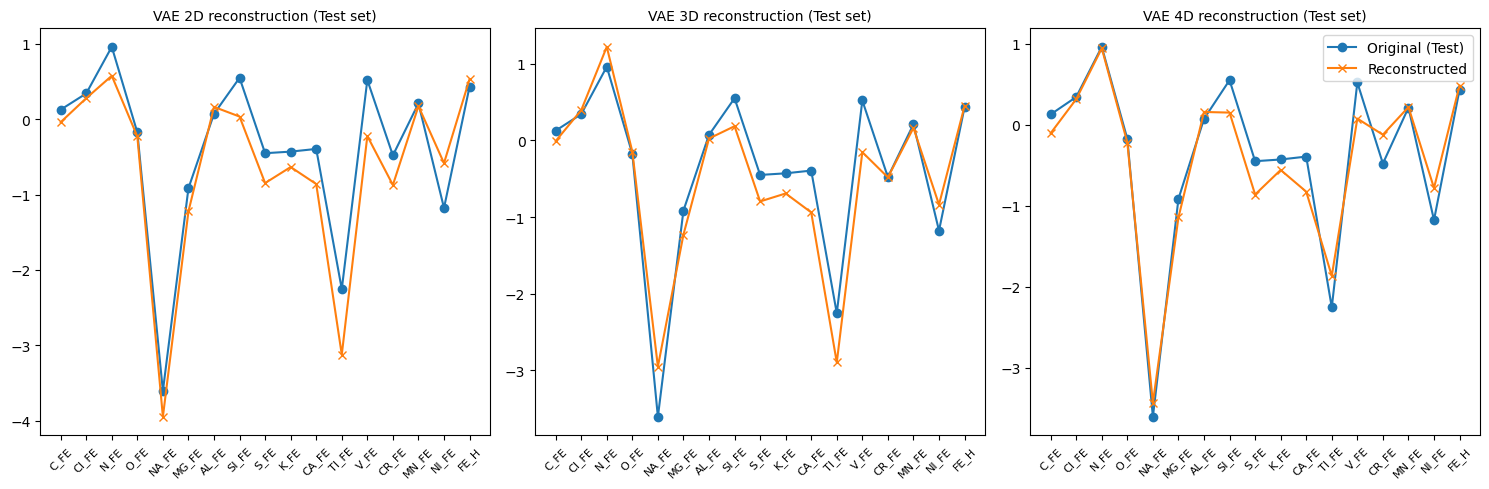

In [8]:
col_names = list(val_data.columns)  # colonnes numériques du test (sans apogee_id)

chosen_id = "2M01064163-0855466"
row_index = data_id_val[data_id_val == chosen_id].index
if len(row_index) == 0:
    raise ValueError(f"Impossible de trouver apogee_id='{chosen_id}' dans le jeu de TEST.")
row_index = row_index[0]
print(f"Étoile choisie (Test set): apogee_id={chosen_id}, row_index={row_index}")

original_abundance = val_data.iloc[row_index].values.astype(np.float32)

# Tenseur correspondant uniquement au jeu de test
x_star_tensor = val_tensor[row_index].unsqueeze(0).to(device)  # shape (1,17)

latent_dims = [2, 3, 4]
reconstructions = {}

for d in latent_dims:
    model = VAE(input_dim=17, latent_dim=d).to(device)

    model_path = os.path.join(weight_folder, f"best_vae_{d}D.pth")
    if not os.path.isfile(model_path):
        print(f"*** Avertissement: Fichier de poids introuvable: {model_path} ***")
        continue

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    with torch.no_grad():
        x_recon, _, _ = model(x_star_tensor)
        x_recon = x_recon.cpu().numpy().flatten()

    reconstructions[d] = x_recon

fig, axes = plt.subplots(1, len(latent_dims), figsize=(5 * len(latent_dims), 5), dpi=100)

if len(latent_dims) == 1:
    axes = [axes]

for idx, d in enumerate(latent_dims):
    ax = axes[idx]
    if d not in reconstructions:
        ax.text(0.5, 0.5, f"{d}D\nNo model", ha='center', va='center', transform=ax.transAxes)
        ax.axis("off")
        continue

    recon = reconstructions[d]
    x = np.arange(len(col_names))

    ax.plot(x, original_abundance, marker='o', label="Original (Test)")
    ax.plot(x, recon, marker='x', label="Reconstructed")

    ax.set_xticks(x)
    ax.set_xticklabels(col_names, rotation=45, fontsize=8)
    ax.set_title(f"VAE {d}D reconstruction (Test set)", fontsize=10)

    if idx == len(latent_dims) - 1:
        ax.legend()

plt.tight_layout()
plt.show()


N_test=32282, Variance totale=16.866136
VAE 2D: MSE=0.306216, Explained Var=0.981844
VAE 3D: MSE=0.242407, Explained Var=0.985628
VAE 4D: MSE=0.195681, Explained Var=0.988398


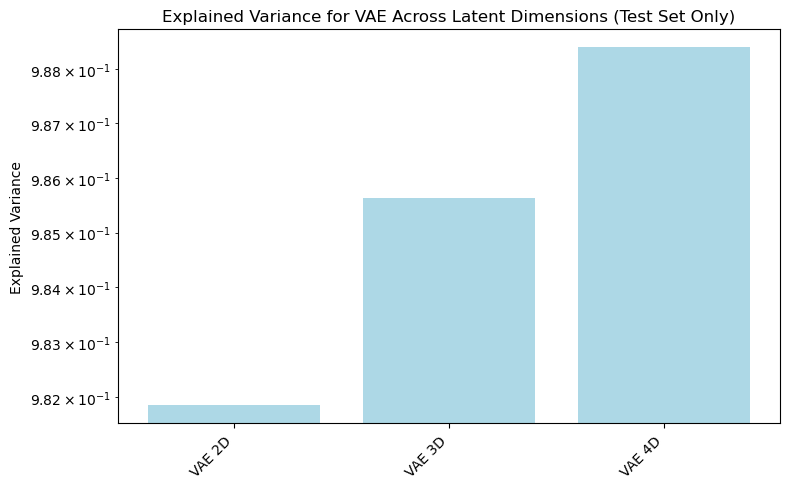

In [9]:
# Utiliser explicitement le jeu de TEST préparé précédemment
val_X_tensor = val_tensor  # déjà au format torch.FloatTensor, shape (N_val, 17)
val_X_np = val_X_tensor.cpu().numpy()

# Calcul précis de la covariance et variance totale uniquement sur le TEST
cov_matrix = np.cov(val_X_np, rowvar=False)
total_variance = np.trace(cov_matrix)
print(f"N_test={len(val_X_np)}, Variance totale={total_variance:.6f}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weight_folder = "output_weight"

latent_dims = [2, 3, 4]
explained_variances_vae = {}

val_X_tensor = val_X_tensor.to(device)

for d in latent_dims:
    model_path = os.path.join(weight_folder, f"best_vae_{d}D.pth")
    if not os.path.isfile(model_path):
        print(f"*** Pas de fichier pour {d}D: {model_path} ***")
        continue

    # Charger explicitement le modèle VAE entraîné
    model = VAE(input_dim=17, latent_dim=d).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Reconstruction explicite uniquement sur le jeu TEST
    with torch.no_grad():
        x_recon_tensor, _, _ = model(val_X_tensor)
    x_recon_np = x_recon_tensor.cpu().numpy()

    # Calculer MSE global sur TEST
    mse_global = np.mean((x_recon_np - val_X_np)**2)

    # Calculer explicitement la variance expliquée sur TEST
    explained_variance = 1.0 - (mse_global / total_variance)
    explained_variances_vae[d] = explained_variance

    print(f"VAE {d}D: MSE={mse_global:.6f}, Explained Var={explained_variance:.6f}")

# ---------------------------------------------------
# Diagramme clair de la variance expliquée (TEST uniquement)
# ---------------------------------------------------
labels = [f"VAE {d}D" for d in latent_dims if d in explained_variances_vae]
ev_values = [explained_variances_vae[d] for d in latent_dims if d in explained_variances_vae]

plt.figure(figsize=(8, 5))
plt.bar(range(len(labels)), ev_values, color='lightblue')
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.ylabel("Explained Variance")
plt.yscale("log")
plt.title("Explained Variance for VAE Across Latent Dimensions (Test Set Only)")
plt.tight_layout()
plt.show()
